# Weight Evolution Analysis

Compares two trained policies:
- **A (10M steps)**: `optuna_ftr_10972867_160/policy_final.pth`  
- **B (62M steps)**: `train_ftr_11001809/attempt_0/policy_final.pth`

**Questions answered:**
1. How different are the two final policies, layer by layer?
2. How does the 62M run diverge from the 10M final as training continues?
3. Which layer groups diverge fastest / latest?

In [2]:
from pathlib import Path
import re

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

LOGS = Path("/home/robot/workspaces/robot_rodeo_gym_ws/logs")

# Reference: 10M-step final
REF_PATH  = LOGS / "optuna_ftr_10972867/optuna_ftr_10972867_160/weights"
# Long run: 62M-step checkpoints
LONG_PATH = LOGS / "train_ftr_11001809/attempt_0/weights"

def load(path: Path) -> dict:
    return torch.load(str(path), map_location="cpu", weights_only=True)

def step_from_name(p: Path) -> int:
    m = re.search(r'step_(\d+)', p.stem)
    return int(m.group(1)) if m else -1

# ── collect checkpoints ──────────────────────────────────────────────
ref_ckpts  = sorted([p for p in REF_PATH.glob("policy_step_*.pth")],  key=step_from_name)
long_ckpts = sorted([p for p in LONG_PATH.glob("policy_step_*.pth")], key=step_from_name)

ref_final  = REF_PATH  / "policy_final.pth"
long_final = LONG_PATH / "policy_final.pth"

print(f"Reference (10M) checkpoints : {len(ref_ckpts)} + 1 final")
print(f"Long run  (62M) checkpoints : {len(long_ckpts)} + 1 final")
print(f"\nRef  step range : {step_from_name(ref_ckpts[0])/1e6:.1f}M – {step_from_name(ref_ckpts[-1])/1e6:.1f}M")
print(f"Long step range : {step_from_name(long_ckpts[0])/1e6:.1f}M – {step_from_name(long_ckpts[-1])/1e6:.1f}M")

Reference (10M) checkpoints : 9 + 1 final
Long run  (62M) checkpoints : 49 + 1 final

Ref  step range : 0.1M – 10.5M
Long step range : 0.1M – 62.9M


## Helper: per-layer metrics

In [3]:
def layer_metrics(a: dict, b: dict) -> dict:
    """Return per-layer cos_sim, rel_delta_norm, and summary scalars."""
    common = sorted(set(a) & set(b))
    rows = []
    total_params = 0
    total_sq = 0.0

    for key in common:
        va, vb = a[key].float(), b[key].float()
        if va.shape != vb.shape:
            continue
        delta   = vb - va
        norm_a  = va.norm().item()
        norm_b  = vb.norm().item()
        d_norm  = delta.norm().item()
        flat_a, flat_b = va.flatten(), vb.flatten()
        denom = flat_a.norm() * flat_b.norm()
        cos   = (flat_a @ flat_b / denom).item() if denom > 0 else float("nan")
        rel   = d_norm / max(norm_a, 1e-9)
        total_params += va.numel()
        total_sq     += d_norm ** 2
        rows.append(dict(key=key, cos_sim=cos, rel_delta=rel,
                         norm_a=norm_a, norm_b=norm_b, delta_norm=d_norm,
                         n_params=va.numel()))

    rms = (total_sq / total_params) ** 0.5 if total_params else float("nan")
    mean_cos = float(np.nanmean([r["cos_sim"] for r in rows])) if rows else float("nan")
    return dict(rows=rows, rms_delta=rms, mean_cos=mean_cos, n_params=total_params)

def short_key(key: str, n: int = 40) -> str:
    """Trim layer name to last n chars for display."""
    parts = key.split(".")
    out = parts[-1]
    for p in reversed(parts[:-1]):
        candidate = p + "." + out
        if len(candidate) > n:
            break
        out = candidate
    return out

def group_key(key: str) -> str:
    """Coarse layer group for colouring.
    Key structure:
      CNN encoder : …encoders.FtrFlatObservation.cnn…
      MLP encoder : …encoders.FtrFlatObservation.mlp.mlp…
      Policy head : module.0.module.0.module.1…  (actor MLP)
      Value head  : module.1.module.1…            (critic MLP)
    Most-specific checks first to avoid 'module.1' substring collisions.
    """
    if "encoders" in key and "cnn" in key:
        return "CNN encoder"
    if "encoders" in key and "mlp.mlp" in key:
        return "MLP encoder"
    if key.startswith("module.0.module.0"):
        return "Policy head"
    if key.startswith("module.1"):
        return "Value head"
    return "Other"

GROUP_COLORS = {
    "CNN encoder" : "#4c72b0",
    "MLP encoder" : "#55a868",
    "Policy head" : "#c44e52",
    "Value head"  : "#dd8452",
    "Other"       : "#8172b2",
}

## 1 · Final vs Final: per-layer comparison

In [4]:
wa = load(ref_final)
wb = load(long_final)
final_metrics = layer_metrics(wa, wb)
rows = final_metrics["rows"]

print(f"Total params : {final_metrics['n_params']:,}")
print(f"RMS Δ/elem   : {final_metrics['rms_delta']:.4f}")
print(f"Mean cos_sim : {final_metrics['mean_cos']:.4f}")

Total params : 652,301
RMS Δ/elem   : 0.2978
Mean cos_sim : 0.4697


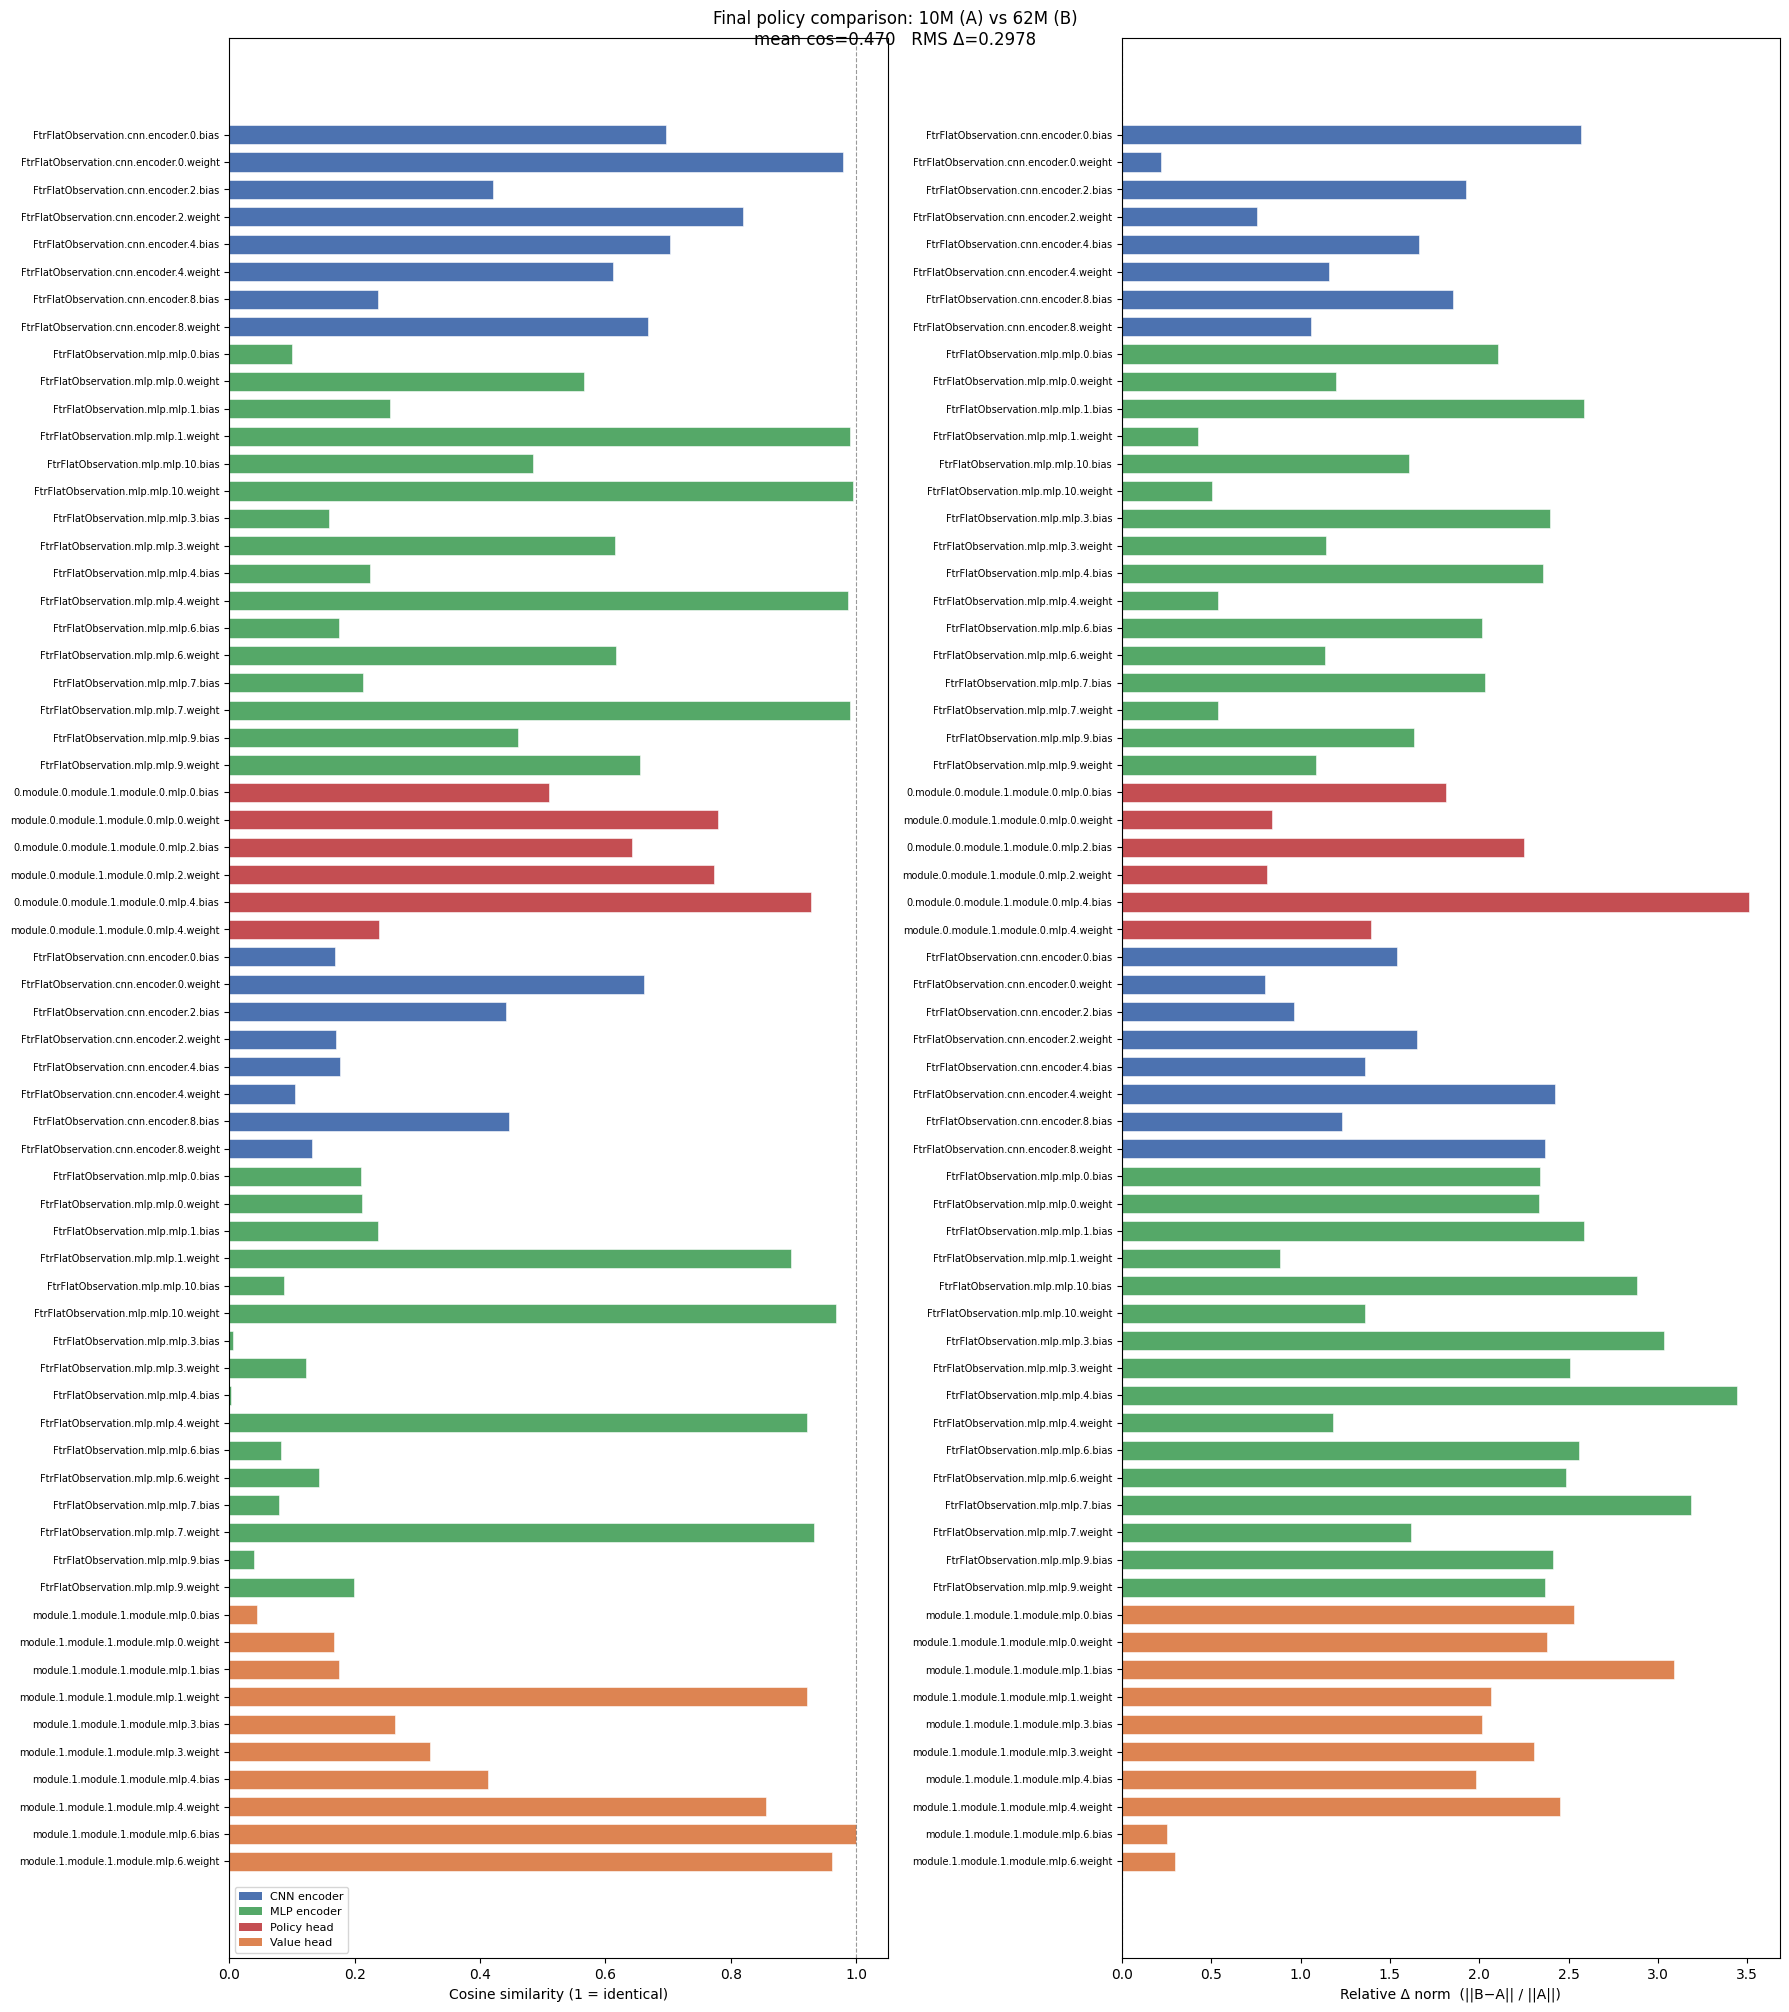

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(rows) * 0.32)))

labels  = [short_key(r["key"]) for r in rows]
colors  = [GROUP_COLORS[group_key(r["key"])] for r in rows]
cos_vals = [r["cos_sim"] for r in rows]
rel_vals = [r["rel_delta"] for r in rows]
y = np.arange(len(rows))

for ax, vals, xlabel, vline in [
    (axes[0], cos_vals, "Cosine similarity (1 = identical)", 1.0),
    (axes[1], rel_vals, "Relative Δ norm  (||B−A|| / ||A||)", 0.0),
]:
    bars = ax.barh(y, vals, color=colors, edgecolor="white", linewidth=0.4, height=0.7)
    ax.axvline(vline, color="black", lw=0.8, ls="--", alpha=0.4)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()

# legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items() if g != "Other"]
axes[0].legend(handles=handles, loc="lower left", fontsize=8)

fig.suptitle(
    f"Final policy comparison: 10M (A) vs 62M (B)\n"
    f"mean cos={final_metrics['mean_cos']:.3f}   RMS Δ={final_metrics['rms_delta']:.4f}",
    fontsize=12
)
fig.tight_layout()
plt.savefig("../images/weight_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

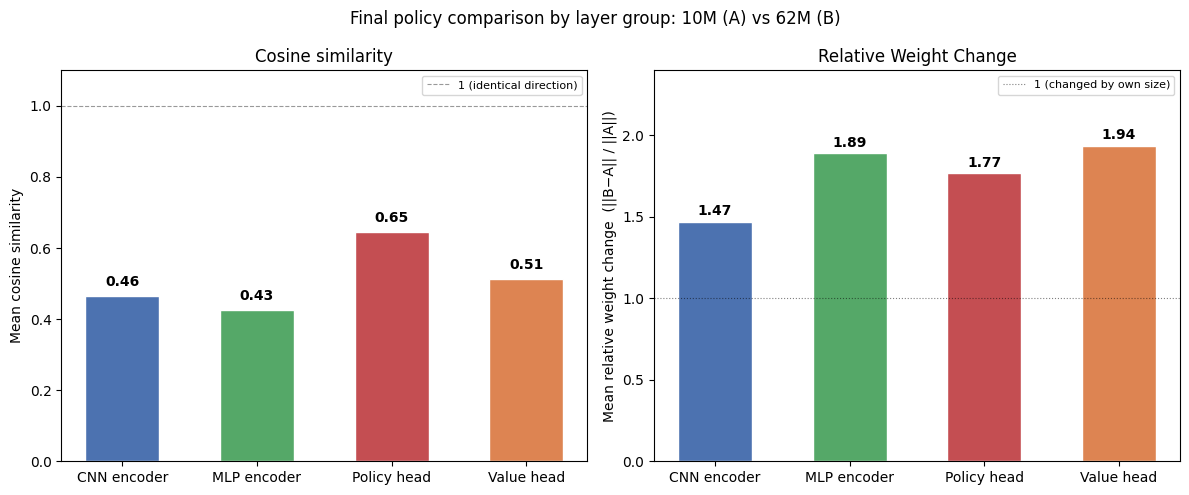

In [22]:
from matplotlib.patches import Patch

group_order = ["CNN encoder", "MLP encoder", "Policy head", "Value head"]

group_cos_final = {g: [] for g in group_order}
group_rel_final = {g: [] for g in group_order}
for r in rows:
    g = group_key(r["key"])
    if g in group_cos_final:
        group_cos_final[g].append(r["cos_sim"])
        group_rel_final[g].append(r["rel_delta"])

labels_g  = group_order
mean_cos  = [np.nanmean(group_cos_final[g]) for g in group_order]
mean_rel  = [np.nanmean(group_rel_final[g]) for g in group_order]
colors_g  = [GROUP_COLORS[g] for g in group_order]

x = np.arange(len(group_order))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── cosine similarity ──────────────────────────────────────────────
bars1 = ax1.bar(x, mean_cos, color=colors_g, edgecolor="white", width=0.55)
ax1.axhline(1.0, color="black", lw=0.8, ls="--", alpha=0.4, label="1 (identical direction)")
ax1.set_xticks(x)
ax1.set_xticklabels(labels_g, fontsize=10)
ax1.set_ylabel("Mean cosine similarity")
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=8)
ax1.set_title("Cosine similarity")
for bar, v in zip(bars1, mean_cos):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── relative delta norm ────────────────────────────────────────────
bars2 = ax2.bar(x, mean_rel, color=colors_g, edgecolor="white", width=0.55)
ax2.axhline(1.0, color="black", lw=0.8, ls=":", alpha=0.5, label="1 (changed by own size)")
ax2.set_xticks(x)
ax2.set_xticklabels(labels_g, fontsize=10)
ax2.set_ylabel("Mean relative weight change  (||B−A|| / ||A||)")
ax2.set_title("Relative Weight Change")
ax2.set_ylim(0,2.4)
ax2.legend(fontsize=8)
for bar, v in zip(bars2, mean_rel):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

fig.suptitle("Final policy comparison by layer group: 10M (A) vs 62M (B)", fontsize=12)
fig.tight_layout()
plt.savefig("../images/weight_group_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 · Weight norm evolution: how each run's weights grow over time

In [7]:
def total_norm(state: dict) -> float:
    vecs = [v.float().flatten() for v in state.values() if v.dtype in (torch.float32, torch.float16, torch.bfloat16)]
    if not vecs:
        return 0.0
    return torch.cat(vecs).norm().item()

# ── 10M run ──────────────────────────────────────────────────────────
ref_steps, ref_norms = [], []
for p in ref_ckpts:
    s = step_from_name(p)
    ref_steps.append(s / 1e6)
    ref_norms.append(total_norm(load(p)))
ref_steps.append(10.5)   # approximate final step
ref_norms.append(total_norm(load(ref_final)))

# ── 62M run ──────────────────────────────────────────────────────────
long_steps, long_norms = [], []
for p in long_ckpts:
    s = step_from_name(p)
    long_steps.append(s / 1e6)
    long_norms.append(total_norm(load(p)))
long_steps.append(step_from_name(long_ckpts[-1]) / 1e6 + 1.3)
long_norms.append(total_norm(load(long_final)))

print(f"Ref  final norm : {ref_norms[-1]:.1f}")
print(f"Long final norm : {long_norms[-1]:.1f}")

Ref  final norm : 129.5
Long final norm : 278.0


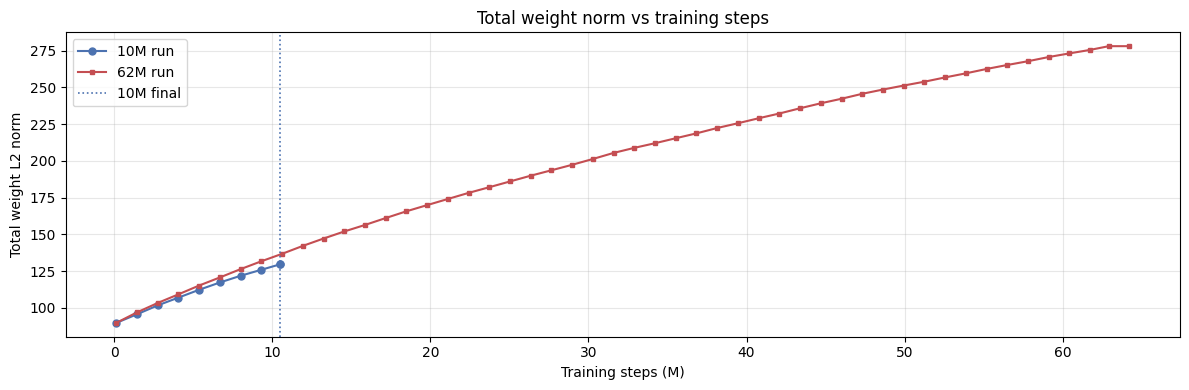

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ref_steps,  ref_norms,  "o-", label="10M run",  color="#4c72b0", ms=5)
ax.plot(long_steps, long_norms, "s-", label="62M run",  color="#c44e52", ms=3, lw=1.5)
ax.axvline(ref_steps[-1], color="#4c72b0", ls=":", lw=1.2, label="10M final")
ax.set_xlabel("Training steps (M)")
ax.set_ylabel("Total weight L2 norm")
ax.set_title("Total weight norm vs training steps")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("../images/weight_norm_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 · Divergence from 10M final: similarity over training steps of the 62M run

For each checkpoint of the 62M run, compute cosine similarity and RMS delta against the 10M final.  
At the moment the 62M run passes 10M steps, both policies should be closest (they were at the same point in training).

In [9]:
ref_w = load(ref_final)  # anchor = 10M final

evo_steps, evo_cos, evo_rms, evo_rel = [], [], [], []

for p in long_ckpts:
    w = load(p)
    m = layer_metrics(ref_w, w)
    evo_steps.append(step_from_name(p) / 1e6)
    evo_cos.append(m["mean_cos"])
    evo_rms.append(m["rms_delta"])
    max_rel = max(r["rel_delta"] for r in m["rows"]) if m["rows"] else float("nan")
    evo_rel.append(max_rel)

# also add the long final
m_final = layer_metrics(ref_w, load(long_final))
evo_steps.append(long_steps[-1])
evo_cos.append(m_final["mean_cos"])
evo_rms.append(m_final["rms_delta"])
evo_rel.append(max(r["rel_delta"] for r in m_final["rows"]))

# find the step closest to 10M in the 62M run
cross_idx = int(np.argmin([abs(s - ref_steps[-1]) for s in evo_steps]))
print(f"Closest ckpt to 10M final: {evo_steps[cross_idx]:.2f}M  "
      f"cos={evo_cos[cross_idx]:.3f}  rms={evo_rms[cross_idx]:.4f}")

Closest ckpt to 10M final: 10.62M  cos=0.575  rms=0.1328


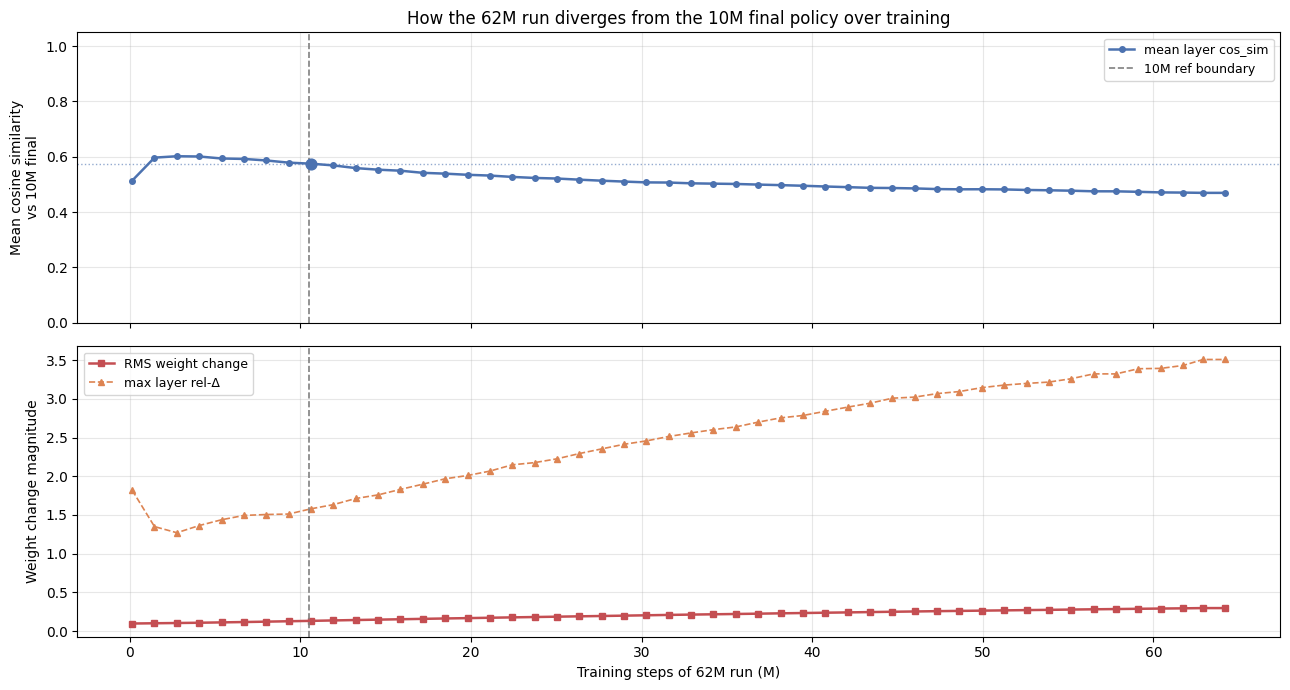

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# ── cosine similarity ──────────────────────────────────────────────
ax1.plot(evo_steps, evo_cos, "o-", color="#4c72b0", ms=4, lw=1.8, label="mean layer cos_sim")
ax1.axvline(ref_steps[-1], color="gray", ls="--", lw=1.2, label="10M ref boundary")
ax1.axhline(evo_cos[cross_idx], color="#4c72b0", ls=":", lw=1, alpha=0.6)
ax1.scatter([evo_steps[cross_idx]], [evo_cos[cross_idx]], color="#4c72b0", zorder=5, s=60)
ax1.set_ylabel("Mean cosine similarity\nvs 10M final")
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_title("How the 62M run diverges from the 10M final policy over training")

# ── RMS delta ──────────────────────────────────────────────────────
ax2.plot(evo_steps, evo_rms, "s-", color="#c44e52", ms=4, lw=1.8, label="RMS weight change")
ax2.plot(evo_steps, evo_rel, "^--", color="#dd8452", ms=4, lw=1.2, label="max layer rel-Δ")
ax2.axvline(ref_steps[-1], color="gray", ls="--", lw=1.2)
ax2.set_ylabel("Weight change magnitude")
ax2.set_xlabel("Training steps of 62M run (M)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig("../images/weight_divergence_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Per-layer cosine similarity heatmap over training

Each row = a layer, each column = a checkpoint of the 62M run. Color shows how similar that layer is to the 10M final.

In [11]:
# ── collect per-layer cos_sim and rel_delta at each ckpt ──────────
all_keys = sorted(set(ref_w.keys()) & set(load(long_final).keys()))

# matrix: rows=layers, cols=checkpoints
cos_matrix = np.full((len(all_keys), len(evo_steps)), np.nan)
rel_matrix  = np.full((len(all_keys), len(evo_steps)), np.nan)

for ci, p in enumerate(long_ckpts):
    w = load(p)
    for li, key in enumerate(all_keys):
        if key not in w or w[key].shape != ref_w[key].shape:
            continue
        va = ref_w[key].float().flatten()
        vb = w[key].float().flatten()
        denom = va.norm() * vb.norm()
        cos_matrix[li, ci] = (va @ vb / denom).item() if denom > 0 else float("nan")
        rel_matrix[li, ci]  = (vb - va).norm().item() / max(va.norm().item(), 1e-9)

# fill the final column
w_final = load(long_final)
for li, key in enumerate(all_keys):
    if key not in w_final or w_final[key].shape != ref_w[key].shape:
        continue
    va = ref_w[key].float().flatten()
    vb = w_final[key].float().flatten()
    denom = va.norm() * vb.norm()
    cos_matrix[li, -1] = (va @ vb / denom).item() if denom > 0 else float("nan")
    rel_matrix[li, -1]  = (vb - va).norm().item() / max(va.norm().item(), 1e-9)

print(f"Matrix shape: {cos_matrix.shape}  (layers × checkpoints)")

Matrix shape: (64, 50)  (layers × checkpoints)


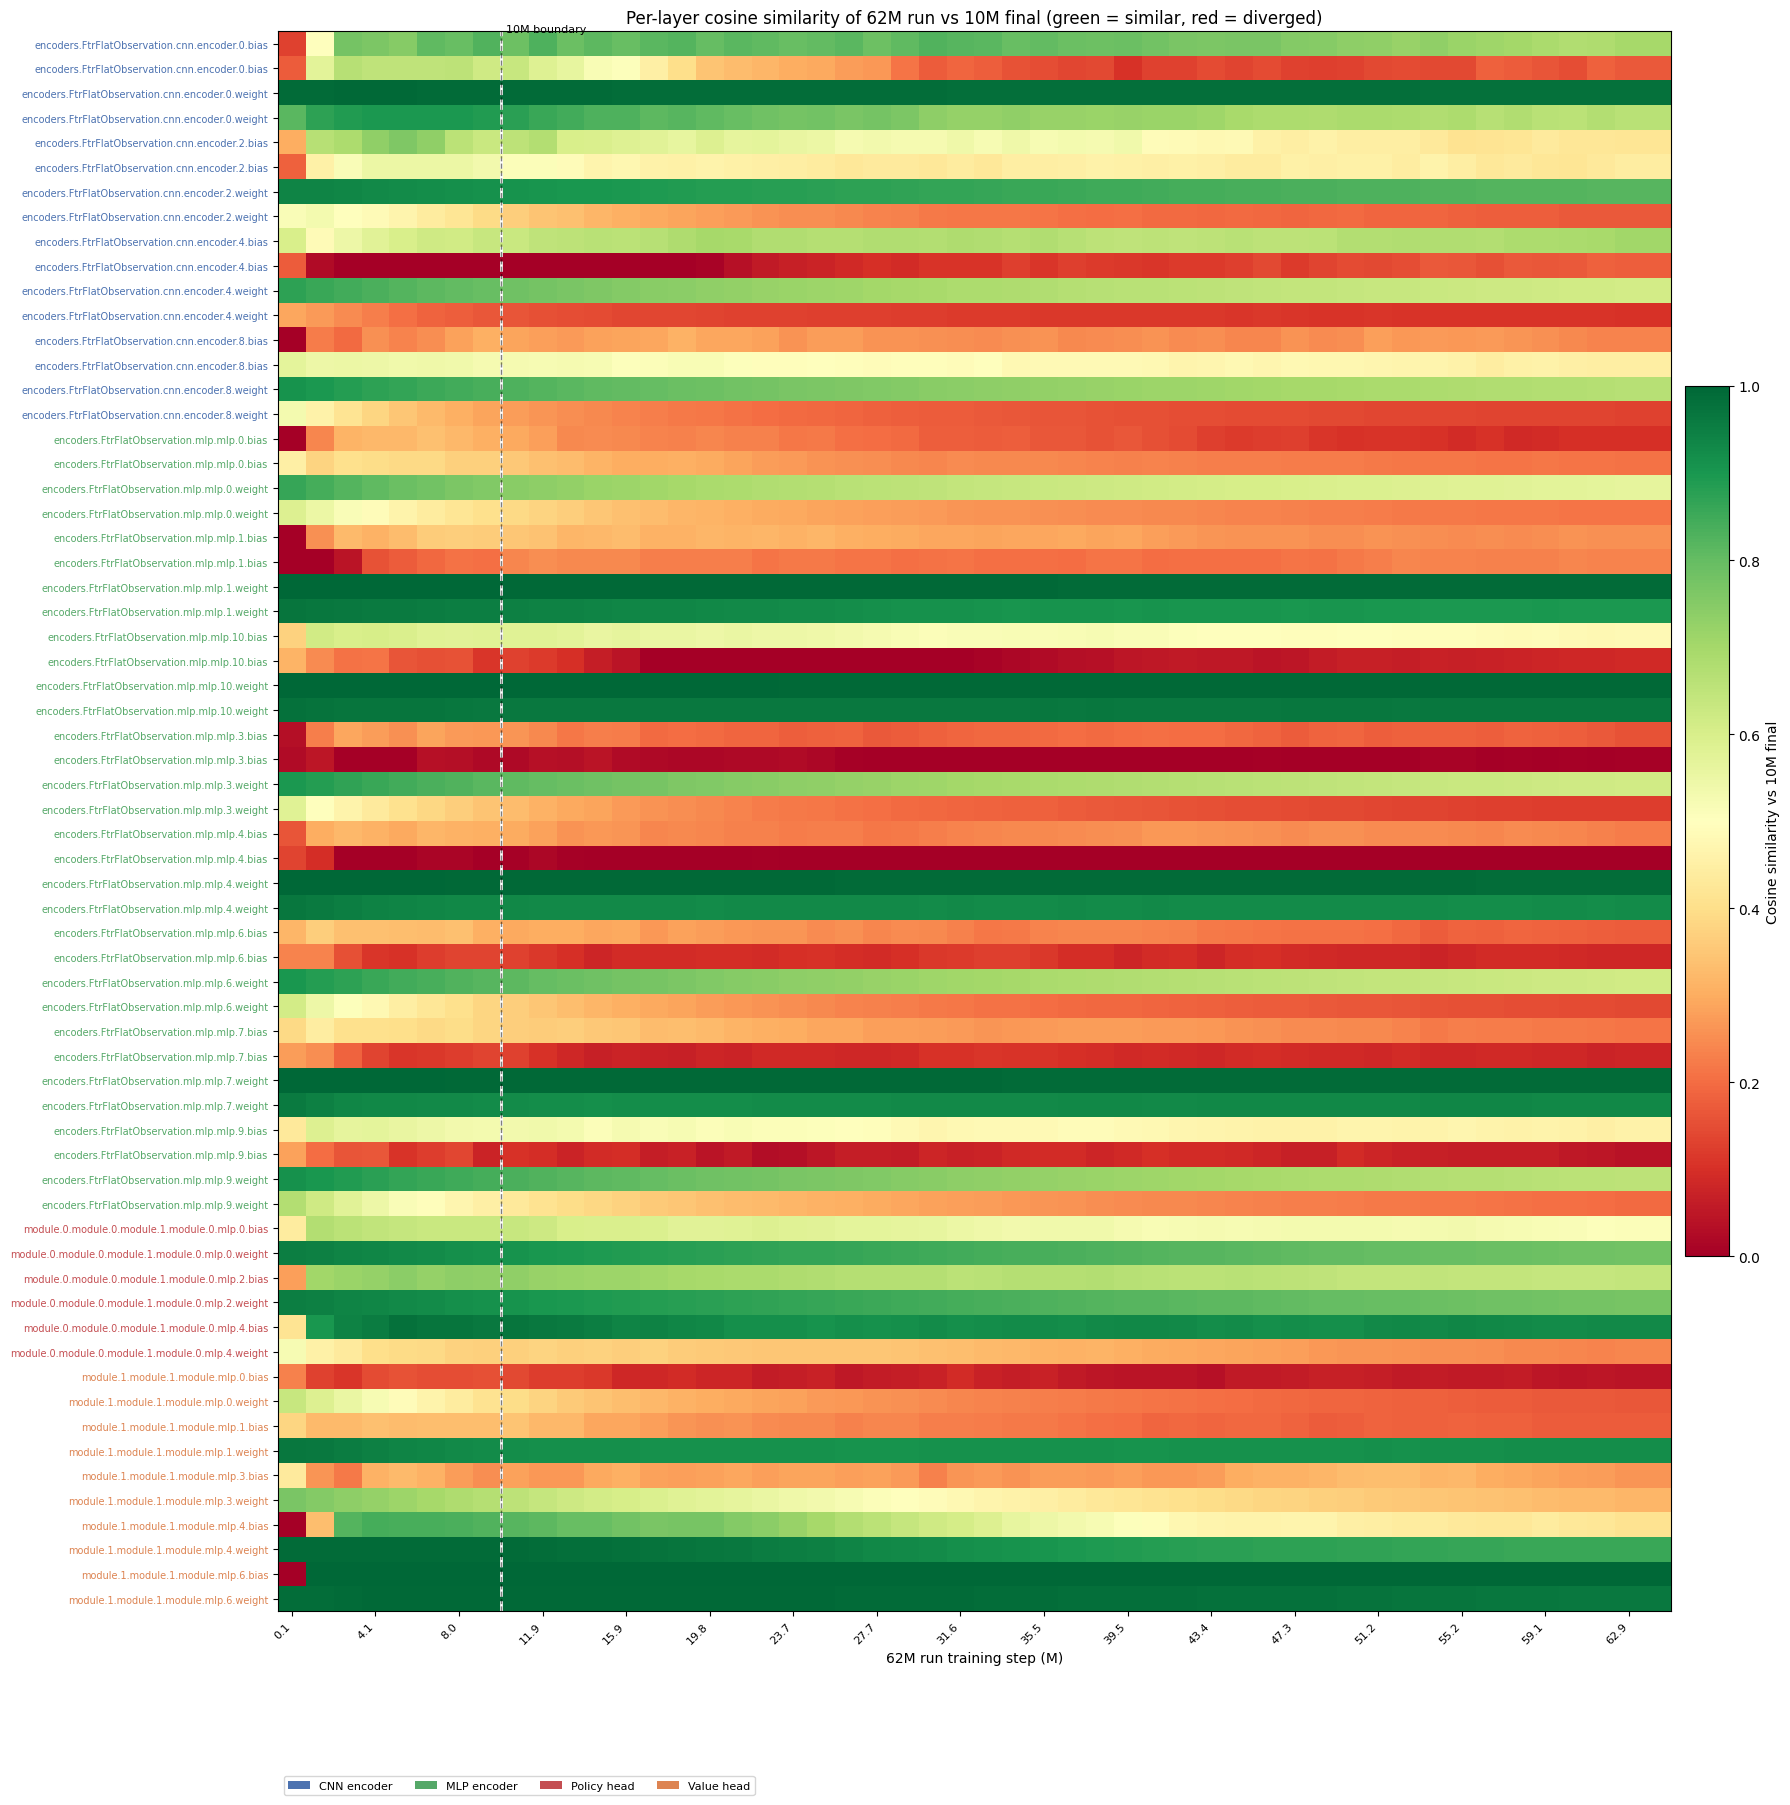

In [12]:
layer_labels = [short_key(k, 48) for k in all_keys]
layer_groups = [group_key(k) for k in all_keys]

# sort by group then name for readability
order = sorted(range(len(all_keys)), key=lambda i: (layer_groups[i], layer_labels[i]))
cos_sorted  = cos_matrix[order, :]
ylabels     = [layer_labels[i] for i in order]
ygroups     = [layer_groups[i] for i in order]

# ── plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, max(8, len(all_keys) * 0.28)))

im = ax.imshow(cos_sorted, aspect="auto", cmap="RdYlGn",
               vmin=0, vmax=1, origin="upper",
               extent=[-0.5, len(evo_steps) - 0.5, len(all_keys) - 0.5, -0.5])

# x-axis: checkpoint steps
xtick_idx  = list(range(len(evo_steps)))
xtick_lbls = [f"{s:.1f}" for s in evo_steps]
ax.set_xticks(xtick_idx[::max(1, len(evo_steps) // 15)])
ax.set_xticklabels(xtick_lbls[::max(1, len(evo_steps) // 15)], fontsize=8, rotation=45, ha="right")
ax.set_xlabel("62M run training step (M)")

# y-axis: layer names with group colour bands
ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels, fontsize=7)

# colour the y tick labels by group
for tick, grp in zip(ax.get_yticklabels(), ygroups):
    tick.set_color(GROUP_COLORS.get(grp, "black"))

# vertical line at ~10M boundary
ax.axvline(cross_idx - 0.5, color="white", lw=2, ls="--")
ax.axvline(cross_idx - 0.5, color="black", lw=1, ls="--", alpha=0.5)
ax.text(cross_idx - 0.3, -0.8, "10M boundary", fontsize=8, color="black", va="top")

plt.colorbar(im, ax=ax, label="Cosine similarity vs 10M final", fraction=0.03, pad=0.01)

# group legend
handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items() if g != "Other"]
ax.legend(handles=handles, loc="lower left", fontsize=8,
          bbox_to_anchor=(0, -0.12), ncol=len(handles))

ax.set_title("Per-layer cosine similarity of 62M run vs 10M final (green = similar, red = diverged)",
             fontsize=12)
fig.tight_layout()
plt.savefig("../images/weight_layer_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Which layer groups diverge earliest?

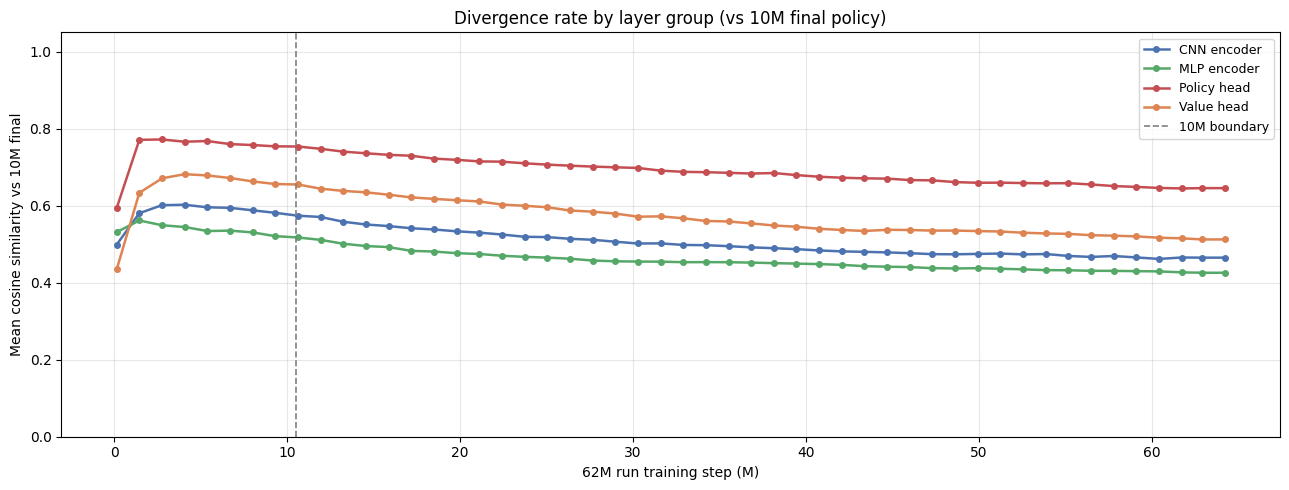

In [13]:
group_names = list(GROUP_COLORS.keys())
group_cos   = {g: [] for g in group_names}

for ci in range(len(evo_steps)):
    col = cos_matrix[:, ci]
    for g in group_names:
        idx  = [i for i, k in enumerate(all_keys) if group_key(k) == g]
        vals = [col[i] for i in idx if not np.isnan(col[i])]
        group_cos[g].append(np.mean(vals) if vals else np.nan)

fig, ax = plt.subplots(figsize=(13, 5))
for g in group_names:
    vals = group_cos[g]
    if all(np.isnan(v) for v in vals):
        continue
    ax.plot(evo_steps, vals, "o-", color=GROUP_COLORS[g], ms=4, lw=1.8, label=g)

ax.axvline(ref_steps[-1], color="gray", ls="--", lw=1.2, label="10M boundary")
ax.set_xlabel("62M run training step (M)")
ax.set_ylabel("Mean cosine similarity vs 10M final")
ax.set_ylim(0, 1.05)
ax.set_title("Divergence rate by layer group (vs 10M final policy)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("../images/weight_group_divergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 5b · Divergence rate by layer group — relative delta norm

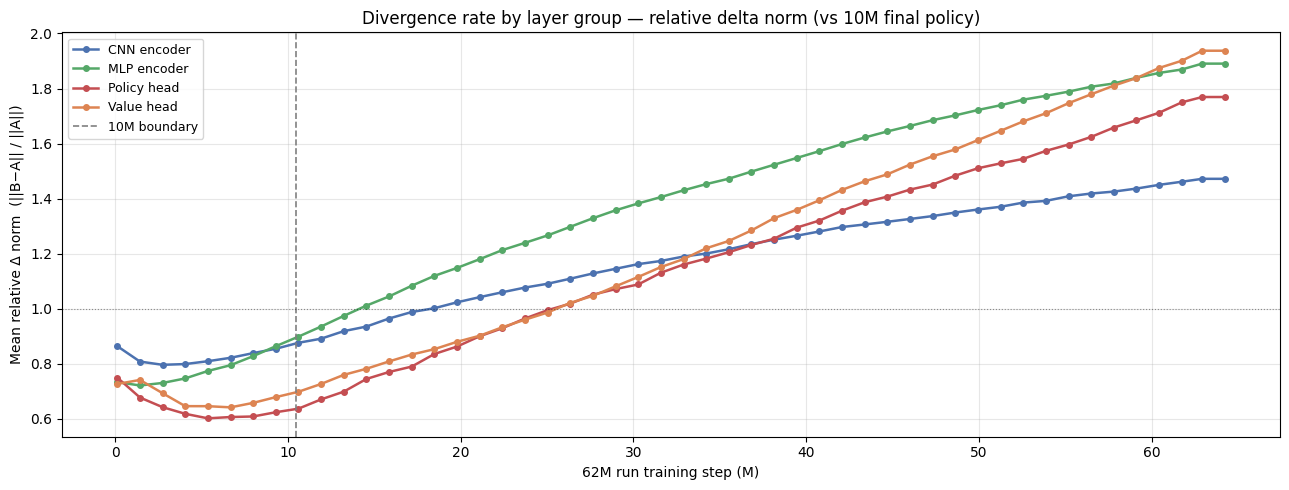

In [14]:
group_rel = {g: [] for g in group_names}

for ci in range(len(evo_steps)):
    col = rel_matrix[:, ci]
    for g in group_names:
        idx  = [i for i, k in enumerate(all_keys) if group_key(k) == g]
        vals = [col[i] for i in idx if not np.isnan(col[i])]
        group_rel[g].append(np.mean(vals) if vals else np.nan)

fig, ax = plt.subplots(figsize=(13, 5))
for g in group_names:
    vals = group_rel[g]
    if all(np.isnan(v) for v in vals):
        continue
    ax.plot(evo_steps, vals, "o-", color=GROUP_COLORS[g], ms=4, lw=1.8, label=g)

ax.axvline(ref_steps[-1], color="gray", ls="--", lw=1.2, label="10M boundary")
ax.axhline(1.0, color="black", ls=":", lw=0.8, alpha=0.4)  # rel_delta=1 reference line
ax.set_xlabel("62M run training step (M)")
ax.set_ylabel("Mean relative Δ norm  (||B−A|| / ||A||)")
ax.set_title("Divergence rate by layer group — relative delta norm (vs 10M final policy)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("../images/weight_group_divergence_rel.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Early-training alignment: 10M run checkpoints vs 62M run checkpoints

Both runs share early checkpoints (131K, 1.4M, 2.7M, 4M, …, ~10M). Compare how similar they are at each shared step to see when they diverge *during* training (before the 10M run ends).

In [15]:
ref_step_map  = {step_from_name(p): p for p in ref_ckpts}
long_step_map = {step_from_name(p): p for p in long_ckpts}

shared_steps = sorted(set(ref_step_map) & set(long_step_map))
print(f"Shared checkpoint steps: {[s//1000 for s in shared_steps]} (×1K)")

shared_s, shared_cos, shared_rms = [], [], []
for s in shared_steps:
    wa = load(ref_step_map[s])
    wb = load(long_step_map[s])
    m  = layer_metrics(wa, wb)
    shared_s.append(s / 1e6)
    shared_cos.append(m["mean_cos"])
    shared_rms.append(m["rms_delta"])
    print(f"  step {s/1e6:.2f}M  cos={m['mean_cos']:.4f}  rms_delta={m['rms_delta']:.5f}")

Shared checkpoint steps: [131, 1441, 2752, 4063, 5373, 6684, 7995, 9306] (×1K)
  step 0.13M  cos=0.6814  rms_delta=0.01350
  step 1.44M  cos=0.6757  rms_delta=0.04960
  step 2.75M  cos=0.6525  rms_delta=0.06761
  step 4.06M  cos=0.6344  rms_delta=0.08089
  step 5.37M  cos=0.6192  rms_delta=0.09341
  step 6.68M  cos=0.6088  rms_delta=0.10428
  step 8.00M  cos=0.5972  rms_delta=0.11484
  step 9.31M  cos=0.5832  rms_delta=0.12437


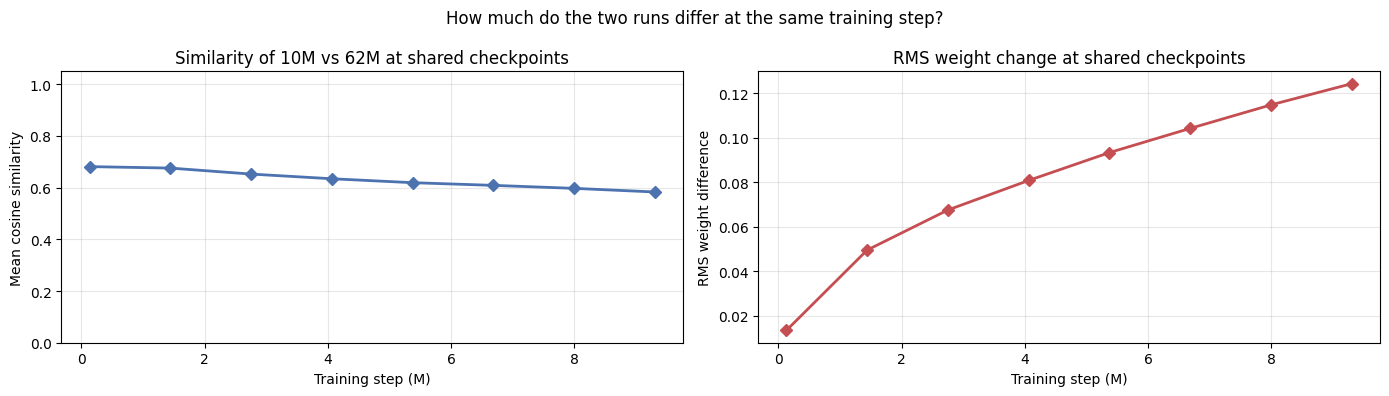

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(shared_s, shared_cos, "D-", color="#4c72b0", ms=6, lw=2)
ax1.set_xlabel("Training step (M)")
ax1.set_ylabel("Mean cosine similarity")
ax1.set_ylim(0, 1.05)
ax1.set_title("Similarity of 10M vs 62M at shared checkpoints")
ax1.grid(True, alpha=0.3)

ax2.plot(shared_s, shared_rms, "D-", color="#c44e52", ms=6, lw=2)
ax2.set_xlabel("Training step (M)")
ax2.set_ylabel("RMS weight difference")
ax2.set_title("RMS weight change at shared checkpoints")
ax2.grid(True, alpha=0.3)

fig.suptitle("How much do the two runs differ at the same training step?", fontsize=12)
fig.tight_layout()
plt.savefig("../images/weight_shared_step_comparison.png", dpi=150, bbox_inches="tight")
plt.show()